# NYC Airbnb Room Type Classification
Dataset:[New York City Airbnb Open DataSet](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data)



# ML lifecycle

**Goal:** Predict the room_type of an Airbnb listing (Entire home/apt, Private room, or Shared room) using listing attributes such as price, location, availability, and review activity.

**What this notebook covers (the full ML lifecycle):**


1.  Problem framing & data loading

2. Exploratory Data Analysis (EDA) — univariate, bivariate, skewness, outliers

3. Data cleaning

4. feature engineering

5. Train / test split
6. Preprocessing with ColumnTransformer + Pipeline

7. Baseline model

8. Multiple candidate algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)

9. Model comparison (cross-validation)

10. Hyperparameter tuning of the best model

11. Final evaluation on the untouched test set

12. Feature importance

13. Saving the final pipeline (model artifact)

14. Conclusion & next steps



# 1. Import Libraries & Load the Dataset

The raw CSV downloaded from Kaggle is read directly into a pandas DataFrame.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))
df.sample(5)

Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
33351,26355142,Private bedroom w/pvt entrance near Times sq. 42D,190921808,John,Manhattan,Hell's Kitchen,40.75505,-73.99531,Private room,120,7,6,2019-06-14,0.50,47,332
23599,19094427,Spacious one bedroom in the heart of Inwood,16020315,Douglas,Manhattan,Inwood,40.86822,-73.92048,Entire home/apt,100,2,9,2019-04-07,0.59,1,0
36996,29412897,Large open space in Bushwick,1949282,Kyla,Brooklyn,Bushwick,40.69418,-73.91140,Private room,36,3,13,2019-06-15,1.51,5,329
8254,6358723,2 Bedroom Duplex,33125859,Sylvia,Brooklyn,Prospect Heights,40.67758,-73.97239,Entire home/apt,145,3,18,2019-06-25,0.37,1,0
26028,20772583,Luxury Apt in the heart of Harlem,21066170,David,Manhattan,Harlem,40.80605,-73.94889,Entire home/apt,150,5,14,2019-05-24,0.67,1,16


# 2. Understanding the Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_int_col = [col for col in df.columns if df[col].dtype == 'int64']
num_float_col = [col for col in df.columns if df[col].dtype == 'float64']

print('Categorical columns:', cat_col)
print('Numerical int columns:', num_int_col)
print('Numerical float columns:', num_float_col)

Categorical columns: ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']
Numerical int columns: ['id', 'host_id', 'price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']
Numerical float columns: ['latitude', 'longitude', 'reviews_per_month']


In [6]:
df.shape

(48895, 16)

In [7]:
df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [8]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


# 3. Exploratory Data Analysis (EDA)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
missing = df.isnull().sum()
missing[missing > 0]

,0
name,16
host_name,21
last_review,10052
reviews_per_month,10052


In [11]:
df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [12]:
df['neighbourhood'].value_counts()

,count
neighbourhood,
Williamsburg,3920
Bedford-Stuyvesant,3714
Harlem,2658
Bushwick,2465
Upper West Side,1971
...,...
Richmondtown,1
Fort Wadsworth,1
New Dorp,1



3.2 Target Variable — room_type

<Axes: xlabel='room_type', ylabel='count'>

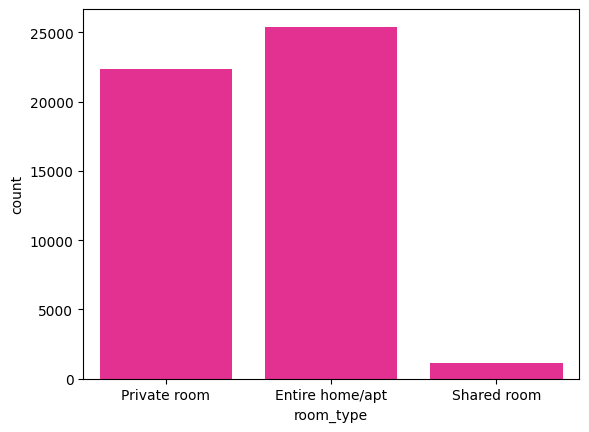

In [13]:
df['room_type'].value_counts()
sns.countplot(x='room_type', data=df, color='deeppink')

In [14]:
num_int_col = [col for col in df.columns if df[col].dtype == 'int64']
print("num_int_col:", num_int_col)

num_int_col: ['id', 'host_id', 'price', 'minimum_nights', 'number_of_reviews', 'calculated_host_listings_count', 'availability_365']



3.3 Univariate Analysis — Numeric Features

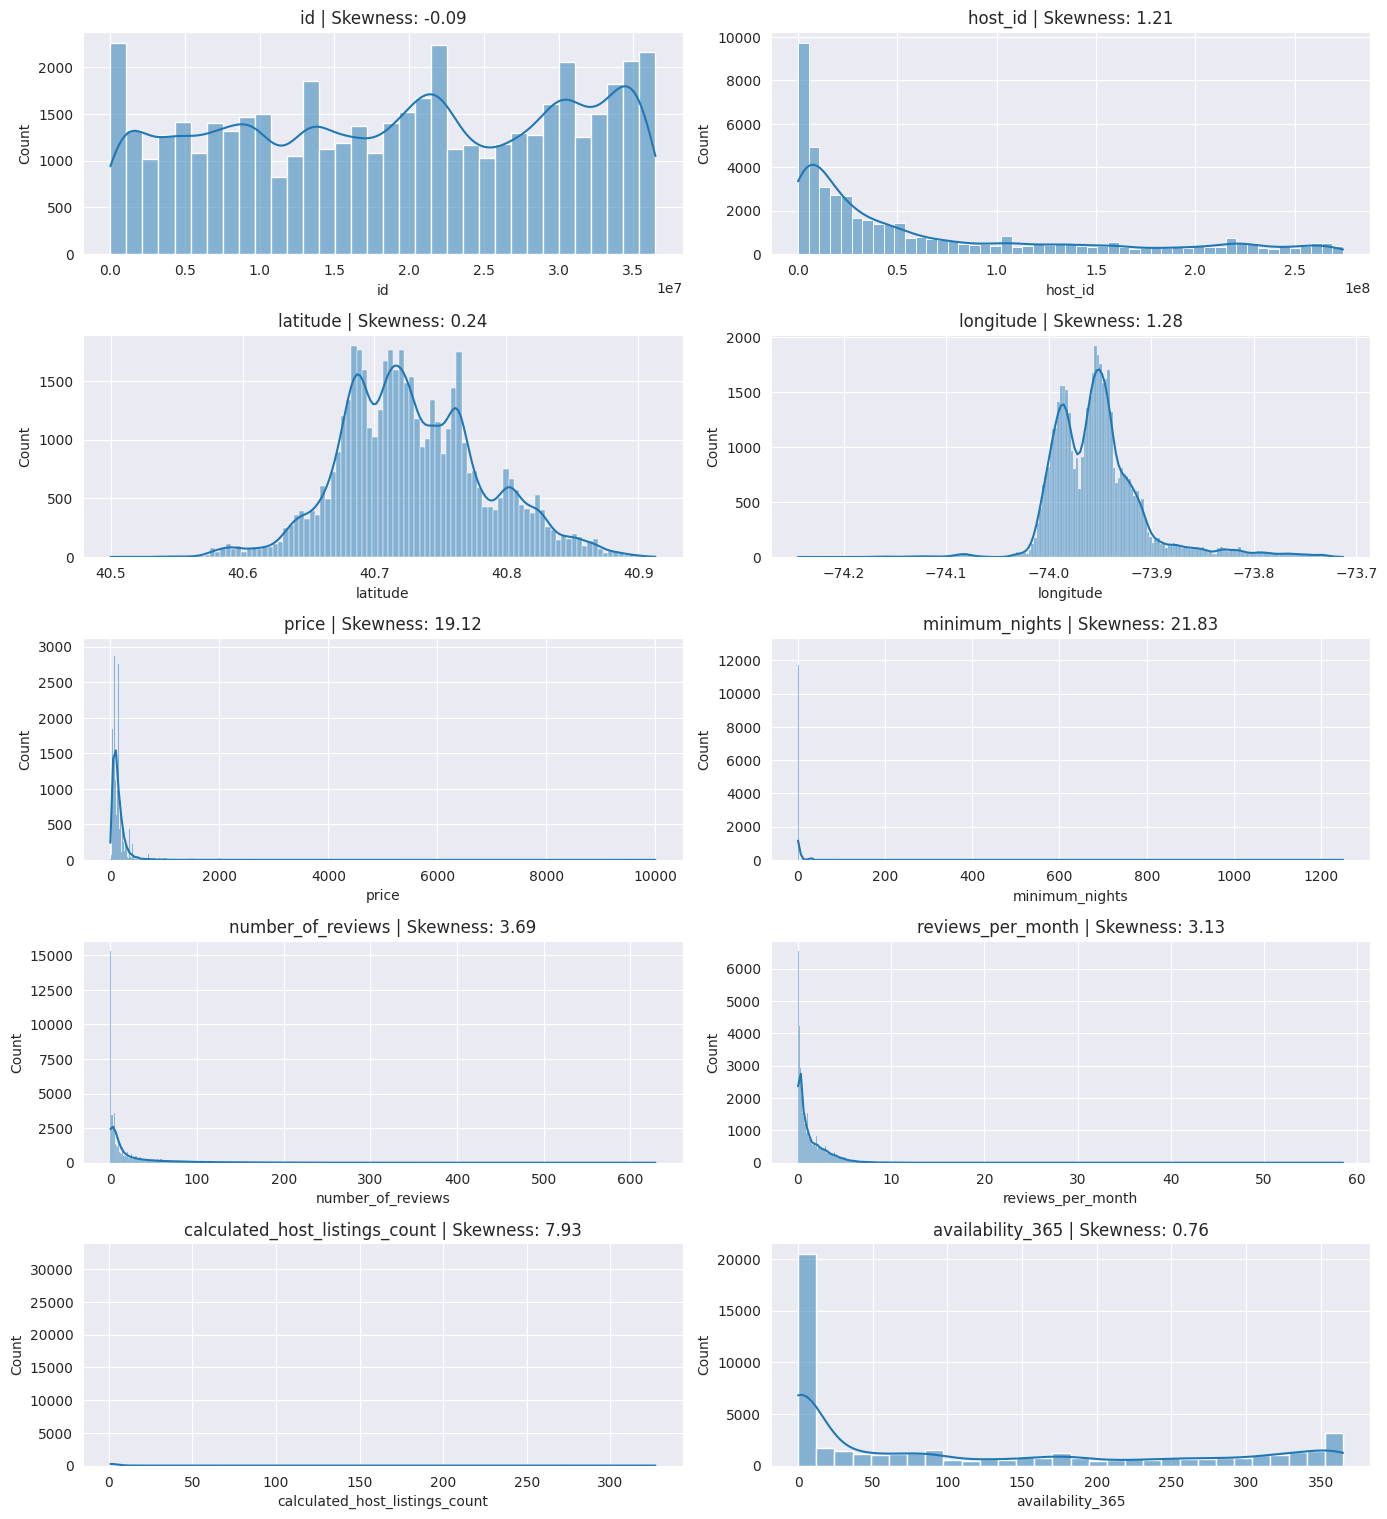

In [15]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()


3.4 Univariate Analysis — Categorical Features

<Axes: xlabel='neighbourhood_group', ylabel='count'>

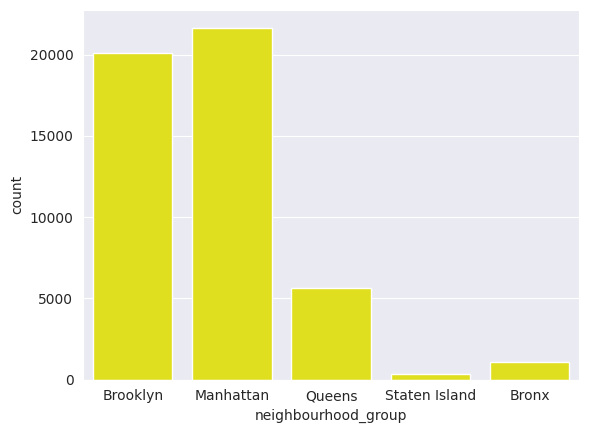

In [16]:
sns.countplot(data=df, x='neighbourhood_group', color='yellow')


3.5 Bivariate Analysis — Features vs Target

<Axes: xlabel='room_type', ylabel='price'>

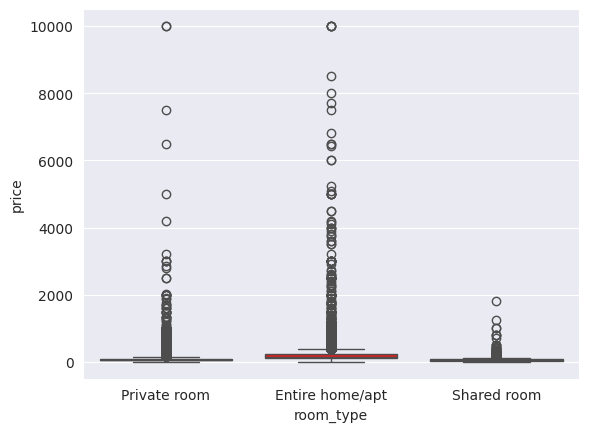

In [17]:
sns.boxplot(x='room_type', y='price', data=df, color='red')

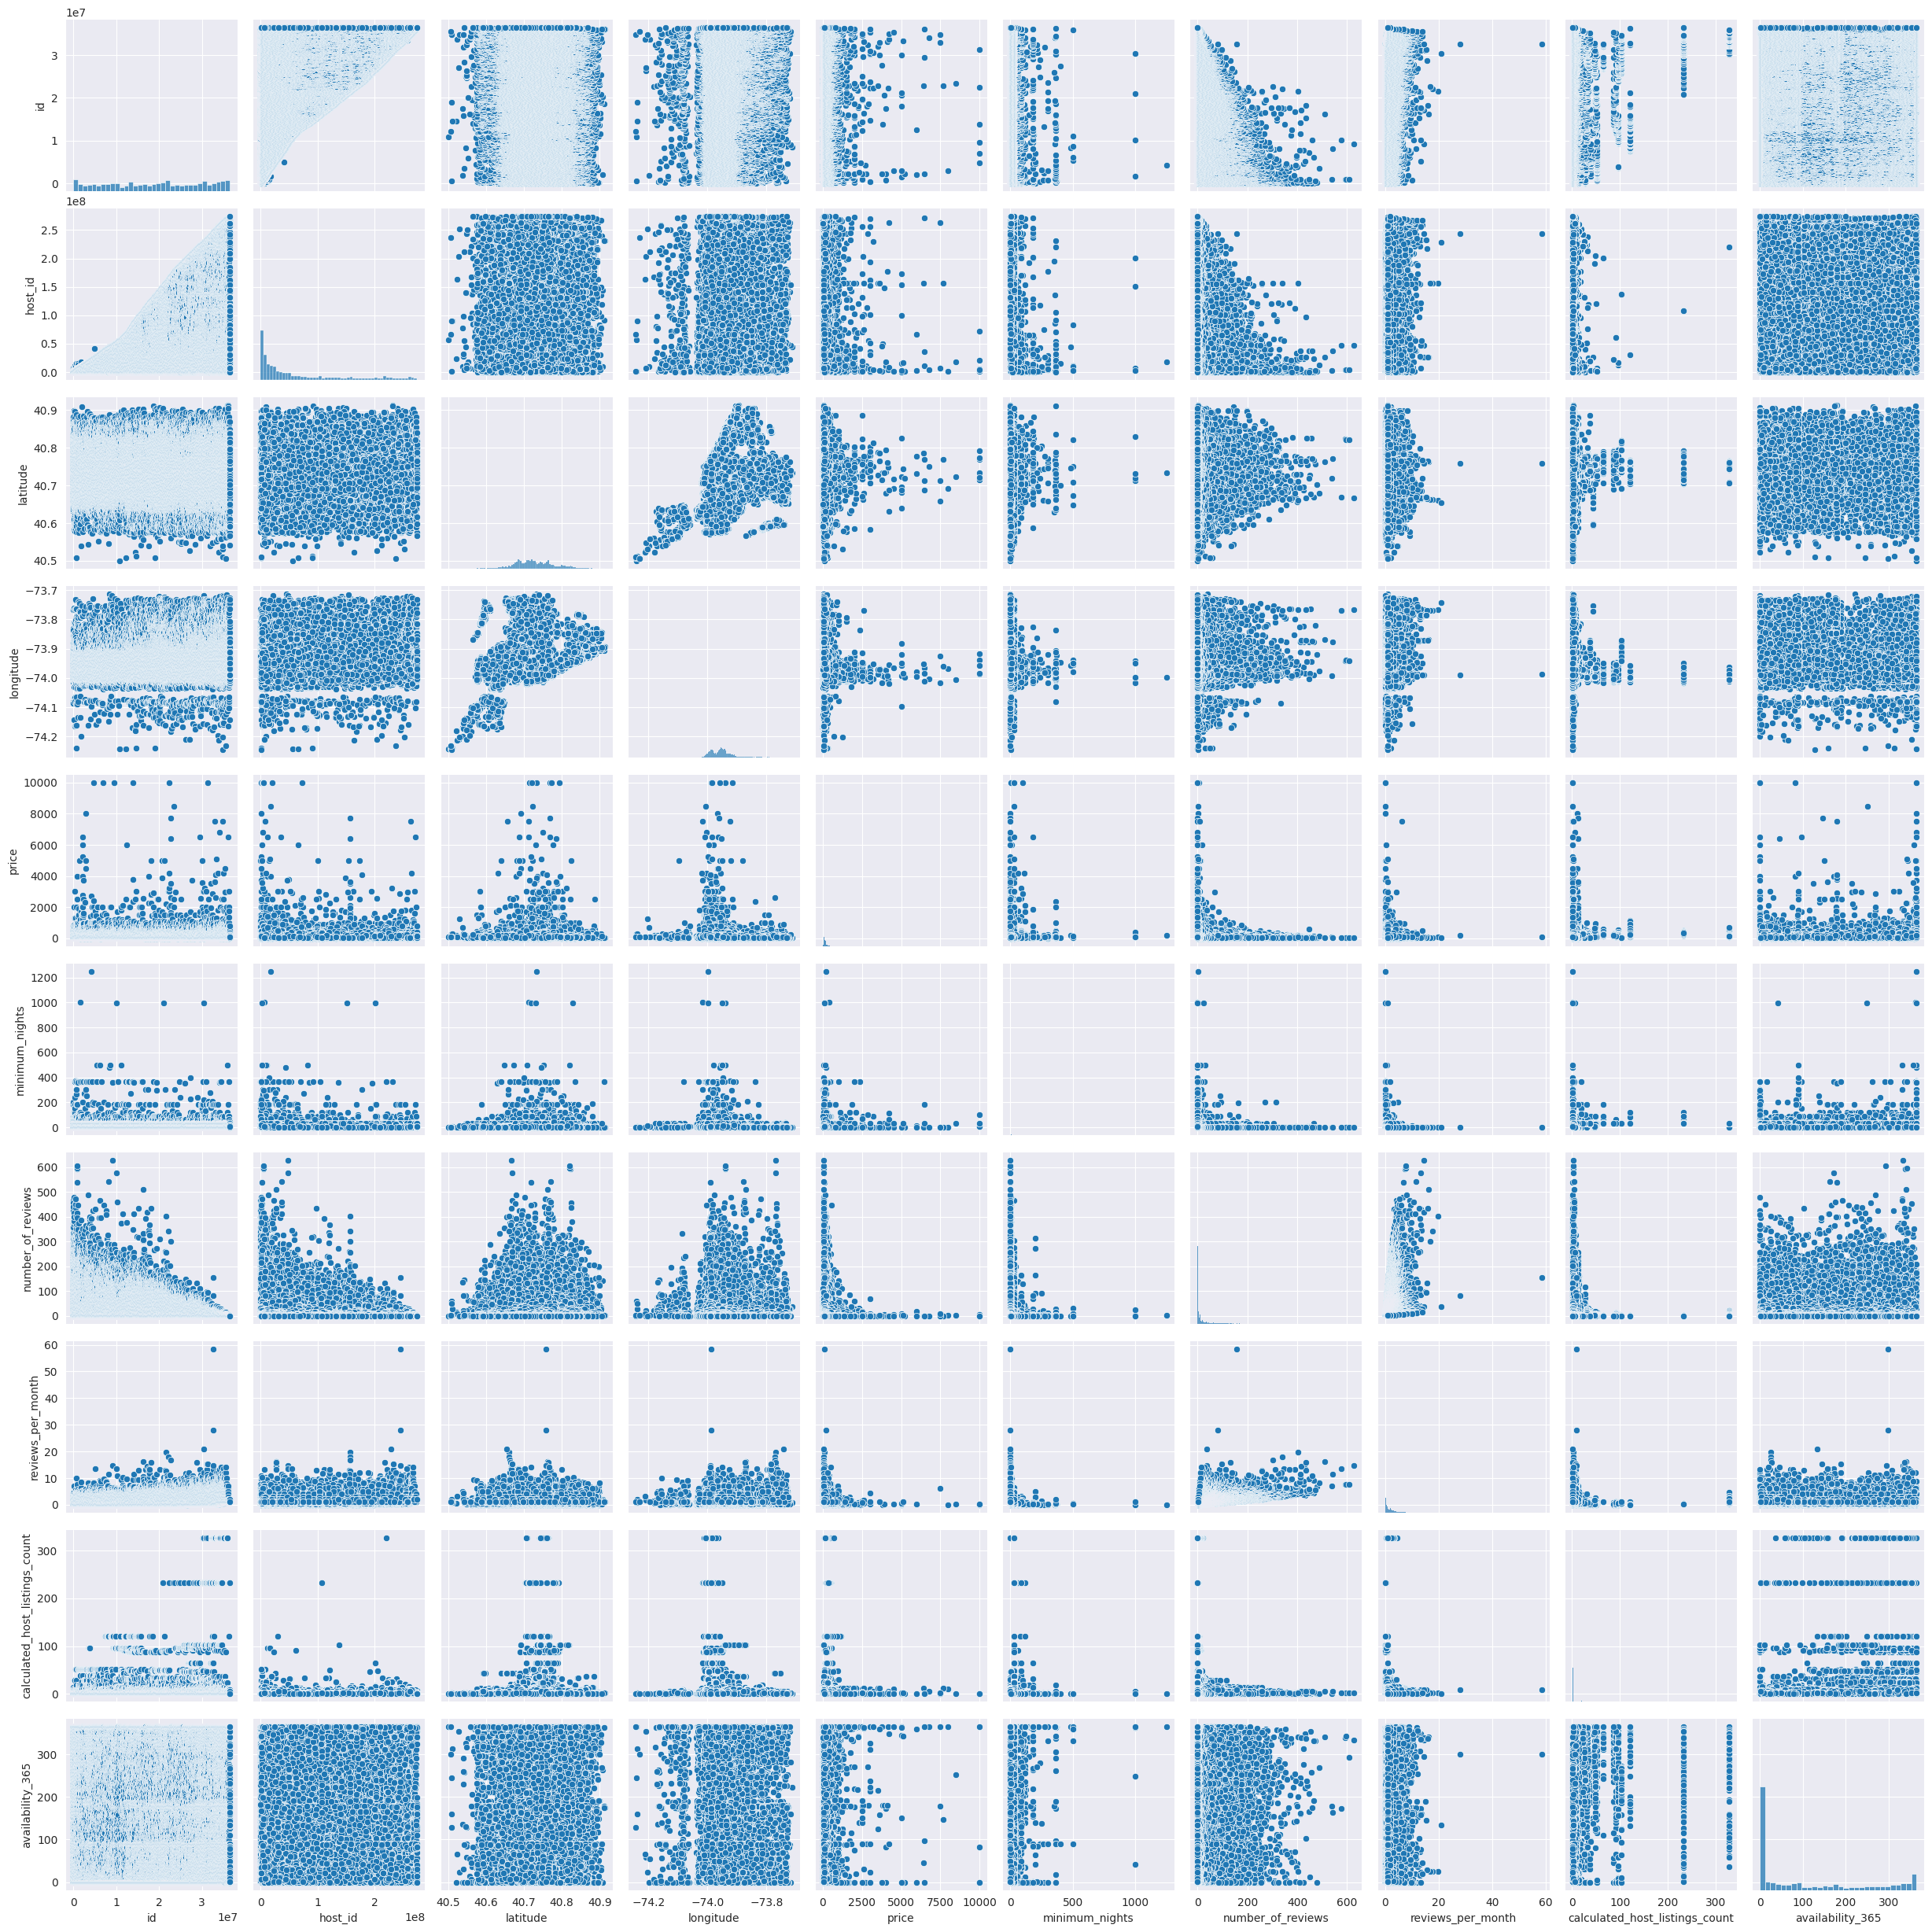

In [18]:
sns.pairplot(df)

Multivariate Analysis
3.6 Correlation Between Numeric Features

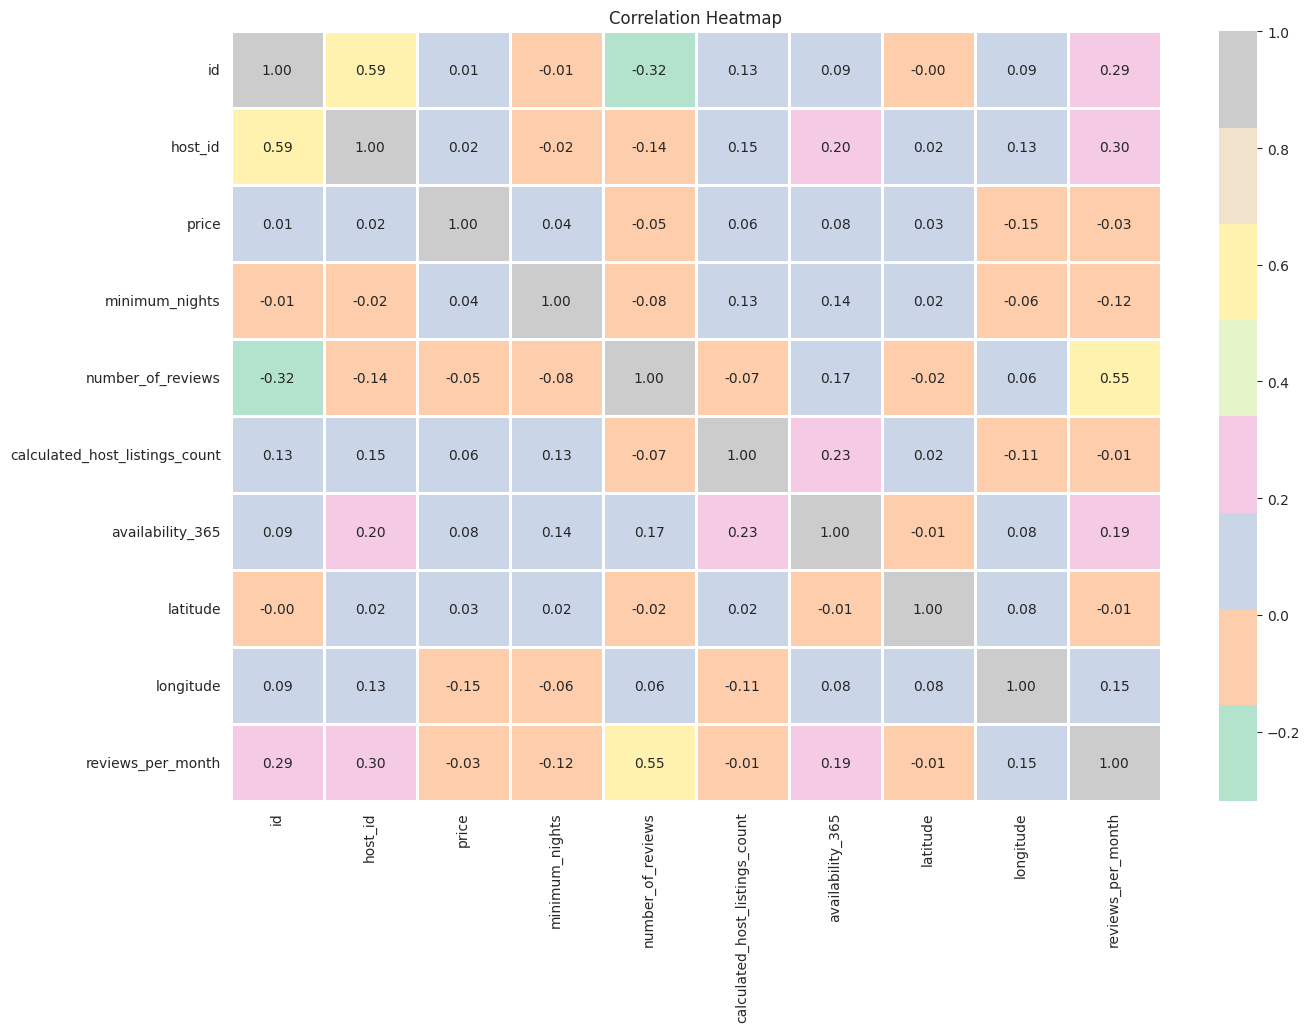

In [19]:
plt.figure(figsize=(15, 10))

sns.heatmap(df[num_int_col + num_float_col].corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()

3.7 Geographic Distribution (Bonus Visual)

<Axes: xlabel='longitude', ylabel='latitude'>

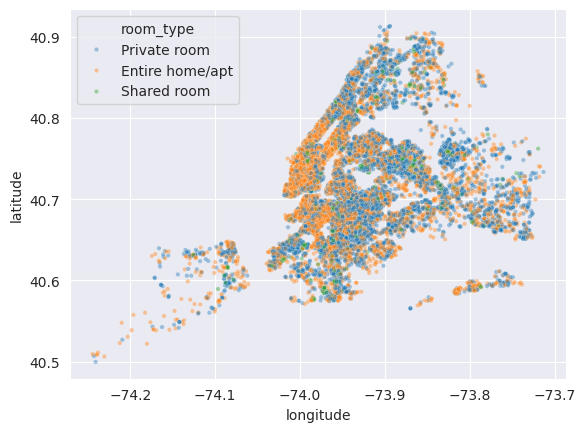

In [20]:
sns.scatterplot(x='longitude', y='latitude',data=df, hue='room_type', alpha=0.4, s=10,)

# 4. Data Cleaning & Feature Engineering

Steps:

1. Drop columns that are pure identifiers or free text and carry no generalizable signal for a tabular model (id, name, host_id, host_name, last_review).

2. Fill missing reviews_per_month with 0 (no reviews yet).

3. Cap extreme outliers in price and minimum_nights using percentile clipping, so a handful of data-entry errors (e.g. $10,000/night, 1,250 minimum nights) don't distort the model.

3. Separate features (X) from the target (y).

In [21]:
# 1. columns that don't help us.

df_clean = df.drop(['id', 'name', 'host_id', 'host_name', 'last_review'], axis=1)

#2. No reviews yet -> 0 reviews per month, not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [22]:
 #3. Cap Extreme outliers instead of deleting rows.

price_cap = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)



#df_clean = df_clean[df_clean['price'] < price_cap]
#df_clean = df_clean[df_clean['minimum_nights'] < nights_cap]


In [23]:
X = df_clean.drop('room_type', axis=1)
y = df_clean['room_type']


In [24]:
df_clean.skew(numeric_only=True)

,0
latitude,0.237167
longitude,1.284210
price,2.776321
minimum_nights,2.360347
number_of_reviews,3.690635
reviews_per_month,3.300723
calculated_host_listings_count,7.933174
availability_365,0.763408


# 5. Train / Test Split


5. Train / Test Split
We hold out 20% of the data as a test set that is never touched during model selection or tuning — it is only used once, at the very end, to report the final, honest performance. stratify=y keeps the same class proportions in both splits, which matters because the target is imbalanced.

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, stratify=y, random_state=42)


#Stratisfy ye ensure krta hai ki jab bhi hum split ya sample kare , har group(class) ka Original Propotion maintain rahe

# 6. Preprocessing: ColumnTransformer + Pipeline

Production ML code should never manually transform train/test data with separate lines — it's error-prone and leaks information. Instead we build a single, reusable ColumnTransformer:

Numeric features → median imputation + standard scaling
Categorical features → most-frequent imputation + one-hot encoding
This transformer will be the first step of every model pipeline below, so preprocessing is learned only on training data and applied consistently everywhere (no data leakage).

In [27]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [28]:
numerical_cols = ["latitude", "longitude", "price", "minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]
categorical_cols = ["neighbourhood_group", "neighbourhood"]

# 1. pipeline for numeric_columns:-
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# 2. Pipeline for Categorical_columns:-
categorical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('scale', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('numerical', numeric_pipeline, numerical_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])

In [29]:
preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['latitude', 'longitude', 'price',
                                  'minimum_nights', 'number_of_reviews',
                                  'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('scale',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

In [30]:
df_clean['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [31]:
df_clean['room_type'].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


# 8. Trying Multiple Algorithms

We now compare several models, each wrapped in its own pipeline with the same preprocessor. We evaluate each with 3-fold stratified cross-validation on the training set (never touching the test set yet), so the comparison is fair and robust.

Models tried:

1. Logistic Regression — simple, interpretable linear baseline

2. Decision Tree — a single non-linear model, prone to overfitting

3. Random Forest — an ensemble of trees, usually a strong general-purpose model

4. Gradient Boosting — sequential ensemble, often the most accurate of the classics

**SMOTE** (Synthetic Minority Oversampling).
for class IMbalance.

1. High chances of overfitting:
2. Data Leakage:

In [32]:
import warnings
warnings.filterwarnings("ignore")

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

* Class_weight="Balanced" tells the model to pay more attention to the minority class
* or rare class (Shared Room)
but the problem is
* GradintBossting doesnt support class weight so we left it as it is.


In [34]:
models = {
    "Logistic Regression" : LogisticRegression(class_weight="balanced", random_state=42),
    "Decision Tree" : DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest" : RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():

  pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])

    # Accuracy alone can be misleading on imbalanced classes, so we use macro f1
    # both: plain accuracy and macro f1 (which treats every class equally)

  accuracy = cross_val_score(pipe, X_train, y_train,cv=3,scoring="accuracy")
  macrof1 = cross_val_score(pipe, X_train, y_train,cv=3,scoring="f1_macro")

  print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")


Logistic Regression -> Accuracy: 0.659 , F1: 0.522
Decision Tree -> Accuracy: 0.782 , F1: 0.647
Random Forest -> Accuracy: 0.851 , F1: 0.715
Gradient Boosting -> Accuracy: 0.850 , F1: 0.705


# 9. Hyperparameter Tuning

We pick the best-performing model from the comparison above (whichever one that turns out to be) and search over its key hyperparameters using RandomizedSearchCV (cheaper than an exhaustive grid search, while still exploring the space well). We keep optimizing for **macro-F1** since the classes are imbalanced.



In [35]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(class_weight='balanced'))
])

param_distribution = {
    "classifier__n_estimators" : [100,200,150,300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
    )

search.fit(X_train, y_train)


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['latitude',
                                                                                'longitude',
                                                                                'price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365']),
                                                                              ('categ...
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('scale',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['neighbourhood_group',
                                                                                'neighbourhood'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced'))]),
                   param_distributions={'classifier__max_depth': [8, 12, 15, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     150,
                                                                     300]},
                   random_state=42, scoring='f1_macro')

In [36]:
print("Best Parameters: ", search.best_params_)
print("Best CV Macro-F1: ", search.best_score_)

Best Parameters:  {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__max_depth': None}
Best CV Macro-F1:  0.7305900023691819


# 10. Final Evaluation on the Test Set


This is the only time we touch the held-out test set. It gives us an honest estimate of how the final tuned model would perform on completely unseen listings.

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix,f1_score
best_pipeline = search.best_estimator_

y_pred = best_pipeline.predict(X_test)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average="macro")}")

Accuracy Score: 0.8554164600892414
F1 Score: 0.7380127109334813


<Axes: >

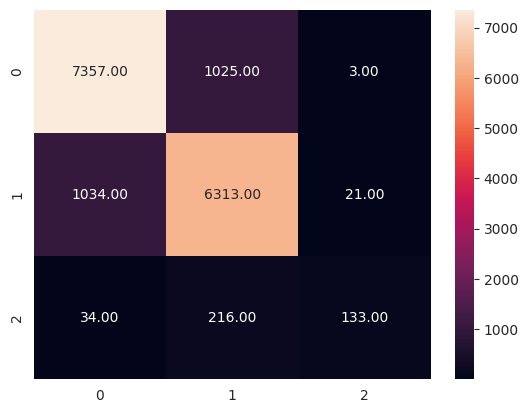

In [38]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt=".2f",
            xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)

# 11. Saving the Final Model Artifact
In production, the entire pipeline (preprocessing and model together) is serialized as a single artifact, so a new listing can be scored with one call no manual preprocessing required at inference time

In [39]:
import joblib

joblib.dump(best_pipeline, "Model_Pipeline.pkl",compress=3)

['Model_Pipeline.pkl']

In [40]:
df_clean.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')